In [ ]:
from galpy.df import eddingtondf
from galpy.potential import PlummerPotential, NFWPotential, HernquistPotential
from tambora.tools import TruncatedNFWPotential, galpy_orbit_to_tambora
import numpy as np
import astropy.units as u

rho0 = 1.0
a = 0.5
amp = rho0 * 4 * np.pi * a**3
rcutoff = 1. #nfwpot.rvir()

ndm = 50_000
nstar = 10_000

dmpot = TruncatedNFWPotential(amp=0.0111077, a=a, rc=rcutoff) #TruncatedNFWPotential(amp=1e9, a=a, rc=rcutoff) #HernquistPotential(amp=1e9 * u.Msun, a=a) #
dmpot.turn_physical_on()
dm_mass = dmpot.mass(rcutoff*4, quantity=True)


starpot = PlummerPotential(amp=dm_mass * 0.1, b=a*0.5)
starpot.turn_physical_on()

mpt_dm = dm_mass / ndm #np.inf) / ndm #rcutoff*4) / ndm
mpt_star = starpot.mass(np.inf, quantity=True) / nstar

#dm_df = eddingtondf(pot=dmpot, rmax=rcutoff*4)
dm_df = eddingtondf(pot=dmpot + starpot, denspot = dmpot, rmax=rcutoff*4)
star_df = eddingtondf(pot=dmpot + starpot, denspot=starpot)
o_dm = dm_df.sample(n=ndm)
o_dm.turn_physical_on()
o_star = star_df.sample(n=nstar)
o_star.turn_physical_on()

pos_dm, vel_dm = galpy_orbit_to_tambora(o_dm)
masses_dm = np.full(len(pos_dm), mpt_dm)

pos_star, vel_star = galpy_orbit_to_tambora(o_star)
masses_star = np.full(len(pos_star), mpt_star)

# pvms_star = np.array([np.array(galpy_orbit_to_tambora(o)) for o in o_star])
# pos_star = pvms_star[:, 0].reshape(-1, 3) 
# vel_star = pvms_star[:, 1].reshape(-1, 3)
# masses_star = np.full(len(pos_star), mpt_star)

UnitConversionError: amp= parameter of TruncatedNFWPotential should have units of None, but has units of mass instead

In [ ]:
dm_mass

<Quantity 3.81271927e+08 solMass>

In [ ]:
starpot.mass(np.inf)

np.float64(38127192.650103204)

In [ ]:
import matplotlib.pyplot as plt

plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['font.size'] = 14
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 18 
plt.rcParams['ytick.labelsize'] = 18
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.top'] = True
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'STIXGeneral'
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True

In [ ]:
from tambora.simulation import Sim
sim = Sim()
sim.add_particles('dm', pos_dm, vel_dm, masses_dm)
sim.add_particles('star', pos_star, vel_star, masses_star)

In [ ]:
mpt_dm, mpt_star

(<Quantity 7625.43853002 solMass>, <Quantity 3812.71926501 solMass>)

(-24.0, 24.0)

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


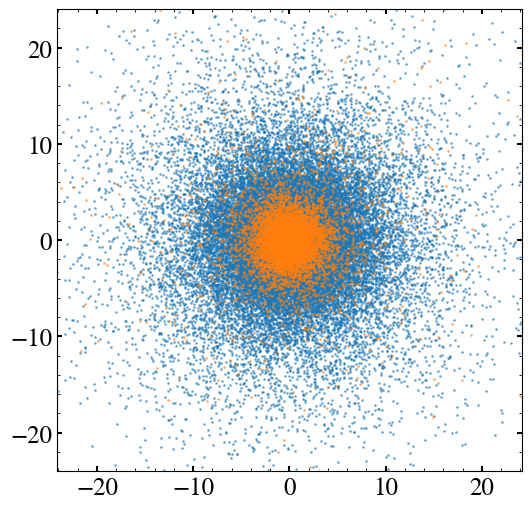

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(sim.dm.x(0), sim.dm.y(0), s=1, alpha=0.5)
plt.scatter(sim.star.x(0), sim.star.y(0), s=1, alpha=0.5)
plt.axis('equal')
plt.xlim(-24, 24)
plt.ylim(-24, 24)

<>:21: SyntaxWarning: invalid escape sequence '\o'

<>:21: SyntaxWarning: invalid escape sequence '\o'

/tmp/ipykernel_48133/2363060451.py:21: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel('Enclosed Mass (M$_\odot$)')



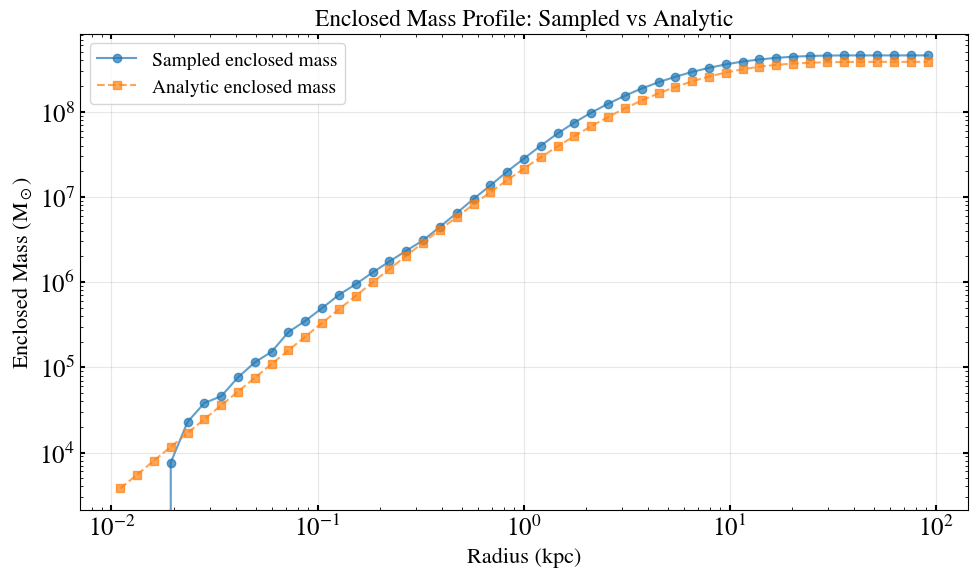

In [ ]:
r_bins = np.logspace(-2, np.log10(rcutoff*100), 50)
r_bin_centers = (r_bins[:-1] + r_bins[1:]) / 2
rsamp = sim.r(0)
rev = sim.r(-1)
hist, _ = np.histogram(rsamp, bins=r_bins)
# Normalize by bin volume (4*pi*r^2*dr)
dr = np.diff(r_bins)
bin_volumes = 4 * np.pi * r_bin_centers**2 * dr
M_sampled = np.zeros_like(r_bin_centers)
for i, r in enumerate(r_bin_centers):
    M_sampled[i] = np.sum(rsamp <= r) * mpt_dm.value  # Normalize by total mass

# Calculate analytic enclosed mass
M_analytic = dmpot.mass(r_bin_centers * u.kpc)#.to(u.Msun).value

# Plot comparison
plt.figure(figsize=(10, 6))
plt.loglog(r_bin_centers, M_sampled, 'o-', label='Sampled enclosed mass', alpha=0.7)
plt.loglog(r_bin_centers, M_analytic, 's--', label='Analytic enclosed mass', alpha=0.7)
plt.xlabel('Radius (kpc)')
plt.ylabel('Enclosed Mass (M$_\odot$)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.title('Enclosed Mass Profile: Sampled vs Analytic')
plt.tight_layout()
plt.show()

In [ ]:
nfw = NFWPotential(amp=1, a=2)
nfw.turn_physical_on()
nfw.mvir()wwwf

np.float64(132709537407.91151)

In [ ]:
NFWPotential 

In [ ]:
sim.run(t_end=2., dt=0.01, dt_out=0.01, eps={'dm':0.01, 'star':0.01}, theta=0.5)#, 'star':0.01})

100%|██████████| 200/200 [00:31<00:00,  6.32it/s]


/geir_data/scr/gabrielspace/tambora/tambora/simulation/simulation.py:1049: UserWarning: Computing external potential on-the-fly for multiple snapshots may be slow.
  warnings.warn("Computing external potential on-the-fly for multiple snapshots may be slow.")



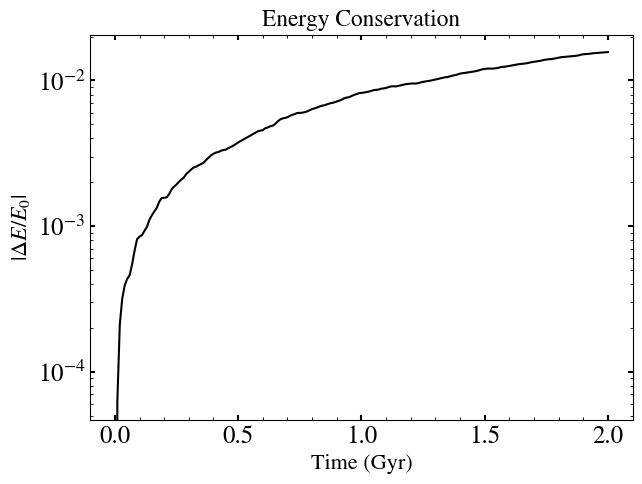

In [ ]:
sim.plot_energy_diagnostic()

In [ ]:

# from matplotlib import animation
# from IPython.display import HTML

# fig, ax = plt.subplots(figsize=(6, 6))
# ax.set_aspect('equal')
# ax.set_xlim(-20, 20)
# ax.set_ylim(-20, 20)
# scatter = ax.scatter(sim.x(0), sim.y(0), s=1, alpha=0.5)
# time_text = ax.text(0.02, 0.95, '', transform=ax.transAxes)

# nframes = len(sim.times)//1

# def animate_frame(frame):
#     frame *= 1
#     xdata = sim.x(frame)
#     ydata = sim.y(frame)
#     scatter.set_offsets(np.column_stack((xdata, ydata)))
#     time_text.set_text(f't = {frame * 0.01:.2f}')
#     return scatter, time_text

# anim = animation.FuncAnimation(fig, animate_frame, frames=nframes, interval=200, blit=True)
# HTML(anim.to_jshtml())

<>:25: SyntaxWarning: invalid escape sequence '\o'

<>:25: SyntaxWarning: invalid escape sequence '\o'

/tmp/ipykernel_48133/2040130339.py:25: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel('Enclosed Mass (M$_\odot$)')



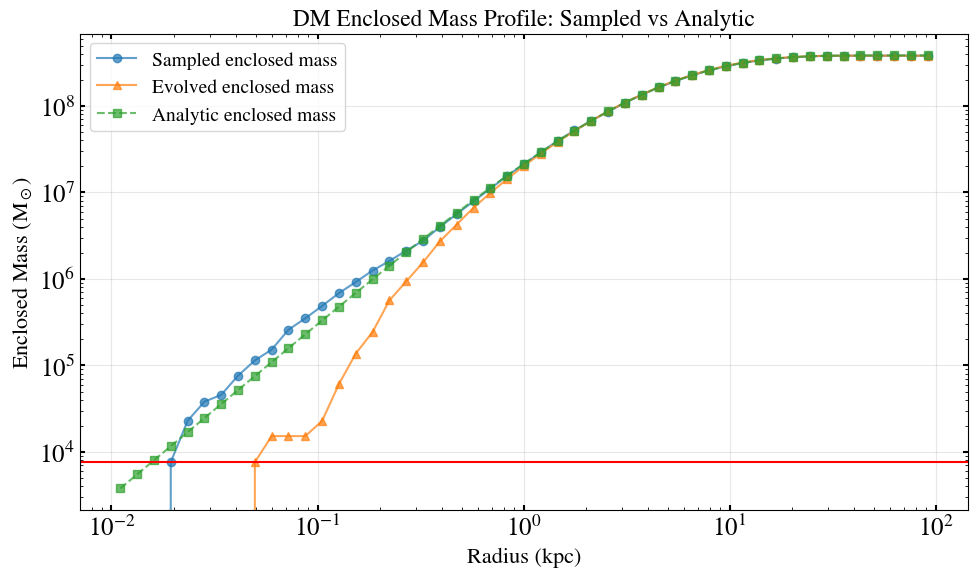

In [ ]:

r_bins = np.logspace(-2, np.log10(rcutoff*100), 50)
r_bin_centers = (r_bins[:-1] + r_bins[1:]) / 2
rsamp = sim.dm.r(0)
rev = sim.dm.r(-1)
hist, _ = np.histogram(rsamp, bins=r_bins)
# Normalize by bin volume (4*pi*r^2*dr)
dr = np.diff(r_bins)
bin_volumes = 4 * np.pi * r_bin_centers**2 * dr
M_sampled = np.zeros_like(r_bin_centers)
M_evolved = np.zeros_like(r_bin_centers)
for i, r in enumerate(r_bin_centers):
    M_sampled[i] = np.sum(rsamp <= r) * mpt_dm.value  # Normalize by total mass
    M_evolved[i] = np.sum(rev <= r) * mpt_dm.value

# Calculate analytic enclosed mass
M_analytic = dmpot.mass(r_bin_centers * u.kpc)#.to(u.Msun).value

# Plot comparison
plt.figure(figsize=(10, 6))
plt.loglog(r_bin_centers, M_sampled, 'o-', label='Sampled enclosed mass', alpha=0.7)
plt.loglog(r_bin_centers, M_evolved, '^-', label='Evolved enclosed mass', alpha=0.7)
plt.loglog(r_bin_centers, M_analytic, 's--', label='Analytic enclosed mass', alpha=0.7)
plt.axhline(mpt_dm.value, color='r')
plt.xlabel('Radius (kpc)')
plt.ylabel('Enclosed Mass (M$_\odot$)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.title('DM Enclosed Mass Profile: Sampled vs Analytic')
plt.tight_layout()
plt.show()

<>:25: SyntaxWarning: invalid escape sequence '\o'

<>:25: SyntaxWarning: invalid escape sequence '\o'

/tmp/ipykernel_48133/730057400.py:25: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel('Enclosed Mass (M$_\odot$)')



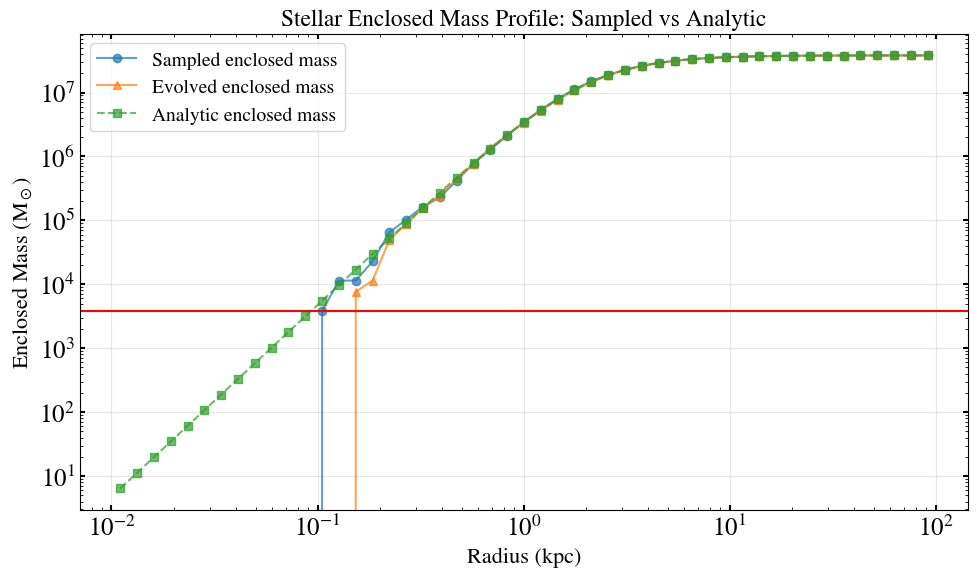

In [ ]:

r_bins = np.logspace(-2, np.log10(rcutoff*100), 50)
r_bin_centers = (r_bins[:-1] + r_bins[1:]) / 2
rsamp = sim.star.r(0)
rev = sim.star.r(-1)
hist, _ = np.histogram(rsamp, bins=r_bins)
# Normalize by bin volume (4*pi*r^2*dr)
dr = np.diff(r_bins)
bin_volumes = 4 * np.pi * r_bin_centers**2 * dr
M_sampled = np.zeros_like(r_bin_centers)
M_evolved = np.zeros_like(r_bin_centers)
for i, r in enumerate(r_bin_centers):
    M_sampled[i] = np.sum(rsamp <= r) * mpt_star.value  # Normalize by total mass
    M_evolved[i] = np.sum(rev <= r) * mpt_star.value

# Calculate analytic enclosed mass
M_analytic = starpot.mass(r_bin_centers * u.kpc)#.to(u.Msun).value

# Plot comparison
plt.figure(figsize=(10, 6))
plt.loglog(r_bin_centers, M_sampled, 'o-', label='Sampled enclosed mass', alpha=0.7)
plt.loglog(r_bin_centers, M_evolved, '^-', label='Evolved enclosed mass', alpha=0.7)
plt.loglog(r_bin_centers, M_analytic, 's--', label='Analytic enclosed mass', alpha=0.7)
plt.axhline(mpt_star.value, color='r')
plt.xlabel('Radius (kpc)')
plt.ylabel('Enclosed Mass (M$_\odot$)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.title('Stellar Enclosed Mass Profile: Sampled vs Analytic')
plt.tight_layout()
plt.show()

In [ ]:
# from matplotlib import animation
# from IPython.display import HTML

# # Radial bins (same as the static plot)
# r_bins = np.logspace(-2, np.log10(rcutoff * 100), 50)
# r_bin_centers = (r_bins[:-1] + r_bins[1:]) / 2

# # Initial-snapshot enclosed mass (constant across frames)
# rsamp = sim.r(0)
# M_sampled = np.array([np.sum(rsamp <= r) * mpt_dm for r in r_bin_centers])

# # Analytic enclosed mass (constant)
# M_analytic = dmpot.mass(r_bin_centers * u.kpc)

# def enclosed_mass(frame):
#     rev = sim.r(frame)
#     return np.array([np.sum(rev <= r) * mpt_dm for r in r_bin_centers])

# skip = 2
# nframes = len(sim.times) // skip

# fig, ax = plt.subplots(figsize=(10, 6))
# ax.set_xscale('log')
# ax.set_yscale('log')
# ax.set_xlabel('Radius (kpc)')
# ax.set_ylabel(r'Enclosed Mass (M$_\odot$)')
# ax.grid(True, alpha=0.3)
# title = ax.set_title('')

# (line_sampled,)  = ax.plot(r_bin_centers, M_sampled,            'o-', label='Sampled (t=0)',   alpha=0.7)
# (line_evolved,)  = ax.plot(r_bin_centers, enclosed_mass(0),     '^-', label='Evolved',         alpha=0.7)
# (line_analytic,) = ax.plot(r_bin_centers, M_analytic,           's--', label='Analytic',       alpha=0.7)
# ax.legend(loc='lower right')

# # Pin the y-limits using the largest evolved profile so the curve doesn't jump out of view
# M_max = max(M_sampled.max(), enclosed_mass(-1).max(), float(np.max(M_analytic)))
# M_min = max(mpt_dm * 0.5, 1.0)
# ax.set_ylim(M_min, M_max * 2)
# ax.set_xlim(r_bin_centers.min(), r_bin_centers.max())

# def update(frame):
#     frame *= skip
#     M_evolved = enclosed_mass(frame)
#     line_evolved.set_ydata(M_evolved)
#     title.set_text(f't = {sim.times[frame]:.2f}')
#     return line_evolved, title

# ani_mass = animation.FuncAnimation(fig, update, frames=nframes, interval=150, blit=False)
# HTML(ani_mass.to_jshtml())

(-24.0, 24.0)

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


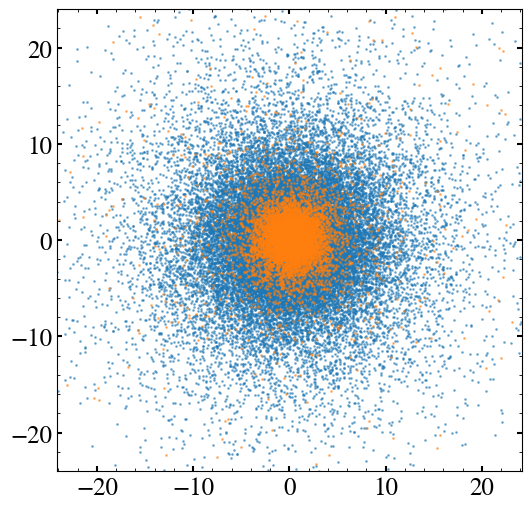

In [ ]:
plt.figure(figsize=(6,6))
#plt.scatter(sim.x(-1), sim.y(-1), s=1, alpha=0.5)
plt.scatter(sim.dm.x(0), sim.dm.y(0), s=1, alpha=0.5)
plt.scatter(sim.star.x(-1), sim.star.y(-1), s=1, alpha=0.5)
plt.axis('equal')
plt.xlim(-24, 24)
plt.ylim(-24, 24)

In [ ]:
from tambora.tools import galpysampler
from tambora.simulation import Sim

pos, vel, masses = galpysampler(n=5000, m_total=mtotal, pot=truncNFW, df_kwargs={'rmax':rcutoff*4})
halo = Sim()
halo.add_particles('halo', pos=pos, vel=vel, mass=masses)
halo.run(4., dt=0.0005, dt_out=0.01, eps=0.01, theta=0.5)

NameError: name 'mtotal' is not defined